In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [9]:
#split data into train and validation sets
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(train)):
    print(f"Fold {fold}: train={len(train_idx)} rows, val={len(val_idx)} rows")

# ambil fold terakhir sebagai train/validation final
train_idx, val_idx = list(tscv.split(train))[-1]

train_sub = train.iloc[train_idx].reset_index(drop=True)
val_sub   = train.iloc[val_idx].reset_index(drop=True)

print(f"\nTrain final : {train_sub.shape}")
print(f"Validation  : {val_sub.shape}")

Fold 0: train=311092 rows, val=311088 rows
Fold 1: train=622180 rows, val=311088 rows
Fold 2: train=933268 rows, val=311088 rows
Fold 3: train=1244356 rows, val=311088 rows
Fold 4: train=1555444 rows, val=311088 rows

Train final : (1555444, 10)
Validation  : (311088, 10)


In [10]:
# drop missing values
train_sub = train_sub.dropna().reset_index(drop=True)
val_sub   = val_sub.dropna().reset_index(drop=True)
test      = test.dropna().reset_index(drop=True)

In [11]:
#change to datetime
train_sub["Date"] = pd.to_datetime(train_sub["Date"])
val_sub["Date"]   = pd.to_datetime(val_sub["Date"])
test["Date"]      = pd.to_datetime(test["Date"])

# train_sub["year"]       = train_sub["Date"].dt.year
# train_sub["month"]      = train_sub["Date"].dt.month
# train_sub["day"]        = train_sub["Date"].dt.day

# val_sub["year"]         = val_sub["Date"].dt.year
# val_sub["month"]        = val_sub["Date"].dt.month
# val_sub["day"]          = val_sub["Date"].dt.day

# test["year"]            = test["Date"].dt.year
# test["month"]           = test["Date"].dt.month
# test["day"]             = test["Date"].dt.day

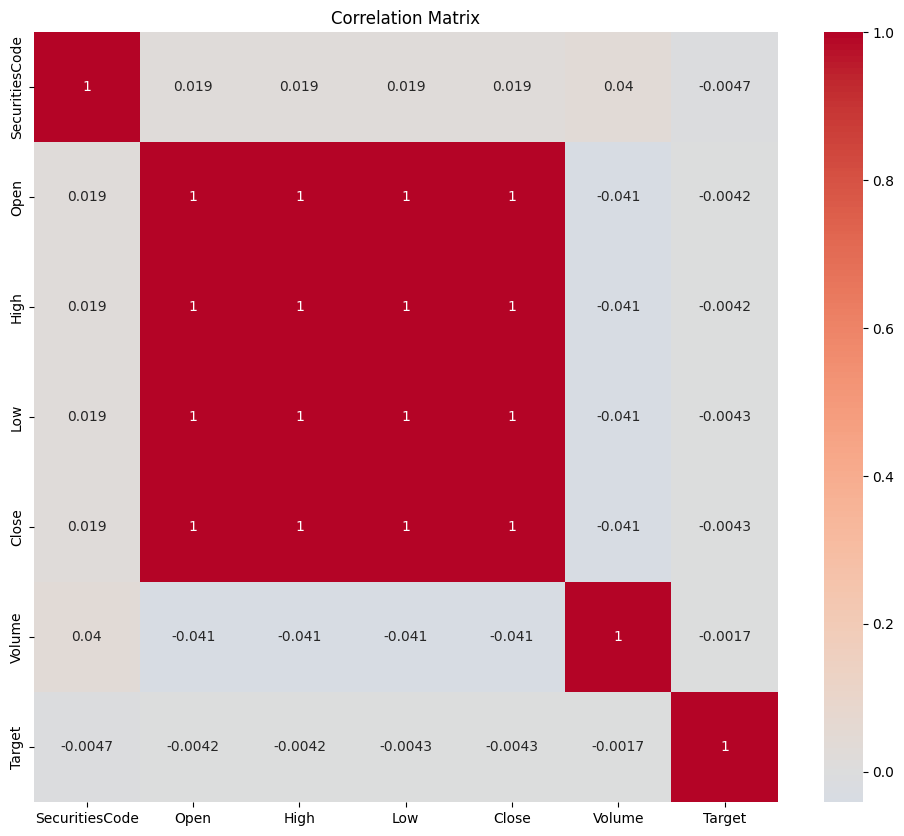

In [12]:
# correlation matrix
corr_data = train_sub.drop(columns=['Unnamed: 0'], errors='ignore')
corr_matrix = corr_data.corr(numeric_only=True)

# plot correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()